In [1]:
#reset all variables
%reset -f

In [ ]:
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMapSolver, ITURadioMaterial, PathSolver
import mitsuba as mi
import numpy as np

#Load scene, assing frequency and
scene = load_scene("room/room.xml",merge_shapes=False)
scene.frequency = 29.5e9 #Hz
scene.synthetic_array = True

#See objects and materials from blender
# for name, obj in scene.objects.items():
#     print(f'{name:<15}{obj.radio_material.name}')

#Apply material and thickness
matAndThick = ITURadioMaterial(name="plasterboard",
                               itu_type="plasterboard",
                               thickness=0.03)#m
obj = scene.get("P2")
obj.radio_material = matAndThick
obj = scene.get("P1")
obj.radio_material = matAndThick

#Configure antennas arrays
scene.tx_array = PlanarArray(
   num_rows=1,
   num_cols=4,
   vertical_spacing=0.5,
   horizontal_spacing=0.5,
   pattern="iso",
   polarization="V")
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

# Transmitter
tx = Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 1.2),
                 orientation=mi.Point3f(0, 0, 0),
                 power_dbm=37)
scene.add(tx)

# Receiver
rx = Receiver(name="rx",
              position=mi.Point3f(-3,5,1.2),
              orientation=(0.0, 0.0, 0.0))
scene.add(rx)
rx = Receiver(name="rx2",
              position=mi.Point3f(3,5,1.2),
              orientation=(0.0, 0.0, 0.0))
scene.add(rx)


#Paths
solver  = PathSolver()
paths = solver(scene,
               max_depth=6,
               max_num_paths_per_src= int(1e6),
               samples_per_src= int(1e6),
               synthetic_array=True,
               los=True,
               specular_reflection=True,
               diffuse_reflection=True,
               refraction=True,
               edge_diffraction=True,
               diffraction_lit_region=True)

# Radio Map
rmSolver = RadioMapSolver()
rm = rmSolver(scene,
              samples_per_tx= int(1e6),
              max_depth=6,
              cell_size=(0.1, 0.1),
              los = True,
              specular_reflection = True,
              diffuse_reflection = True,
              refraction = True,
              diffraction = True,
              edge_diffraction = True,
              diffraction_lit_region = True,
              stop_threshold = -131)

#Ampltiudes and TDoA from CIR
a, tau = paths.cir(out_type="numpy")

print("rx, rx_ant, tx, tx_ant, paths, batch")
print(a.shape)
print("rxs, txs, paths")
print(tau.shape)

nReceptor = 2
tx_power_dbm = 37

print("\n--- RSS ---")

for rx in range(nReceptor):
    amp = a[rx, 0, 0, :, :, 0]
    power = np.sum(np.abs(amp)**2)
    dBPower = tx_power_dbm + 10*np.log10(power + 1e-15)
    print(f"\n[Receptor {rx}] tiene RSS {dBPower:.2f} dBm")



scene.preview(radio_map=rm, clip_at=3)
rm.show(metric='path_gain', vmin=-131)
rm.show(metric='rss', vmin=-100, vmax=-40)

Plane---itu_concrete
C1-1---itu_plasterboard
    -Thickness applied
C1-2---itu_plasterboard
    -Thickness applied
C1-3---itu_plasterboard
    -Thickness applied
C1-4---itu_plasterboard
    -Thickness applied
C1-5---itu_plasterboard
    -Thickness applied
C1-6---itu_plasterboard
    -Thickness applied
C1-7---itu_plasterboard
    -Thickness applied
C1-8---itu_plasterboard
    -Thickness applied
C1-9---itu_plasterboard
    -Thickness applied
C2-1---itu_plasterboard
    -Thickness applied
C2-2---itu_plasterboard
    -Thickness applied
C2-3---itu_plasterboard
    -Thickness applied
C2-4---itu_plasterboard
    -Thickness applied
C2-5---itu_plasterboard
    -Thickness applied
C2-6---itu_plasterboard
    -Thickness applied
C2-7---itu_plasterboard
    -Thickness applied
C2-8---itu_plasterboard
    -Thickness applied
C2-9---itu_plasterboard
    -Thickness applied
C2-10---itu_plasterboard
    -Thickness applied
C2-11---itu_plasterboard
    -Thickness applied
C2-12---itu_plasterboard
    -Thickne

rx, rx_ant, tx, tx_ant, paths, batch
(22, 1, 1, 4, 273, 1)
rxs, txs, paths
(22, 1, 273)

--- RSS ---

Receptor 0 ubicado en (-6.5, 4)tiene RSS -42.70 dBm

Receptor 1 ubicado en (-4, 3)tiene RSS -44.00 dBm

Receptor 2 ubicado en (-2, 3)tiene RSS -58.63 dBm

Receptor 3 ubicado en (0, 3)tiene RSS -70.65 dBm

Receptor 4 ubicado en (1, 1.2)tiene RSS -54.40 dBm

Receptor 5 ubicado en (-2, 1.2)tiene RSS -59.47 dBm

Receptor 6 ubicado en (-6, 1.2)tiene RSS -22.90 dBm

Receptor 7 ubicado en (-4.5, 1.2)tiene RSS -40.14 dBm

Receptor 8 ubicado en (-5.3, -0.5)tiene RSS -34.64 dBm

Receptor 9 ubicado en (-2.5, 0.2)tiene RSS -48.45 dBm

Receptor 10 ubicado en (0.5, 0.5)tiene RSS -68.76 dBm

Receptor 11 ubicado en (2.5, 1)tiene RSS -60.74 dBm

Receptor 12 ubicado en (3, -1)tiene RSS -71.78 dBm

Receptor 13 ubicado en (1, -2)tiene RSS -63.12 dBm

Receptor 14 ubicado en (-2, -2)tiene RSS -53.48 dBm

Receptor 15 ubicado en (-5.3, -2.5)tiene RSS -41.64 dBm

Receptor 16 ubicado en (-7, -2.5)tiene RSS -38.

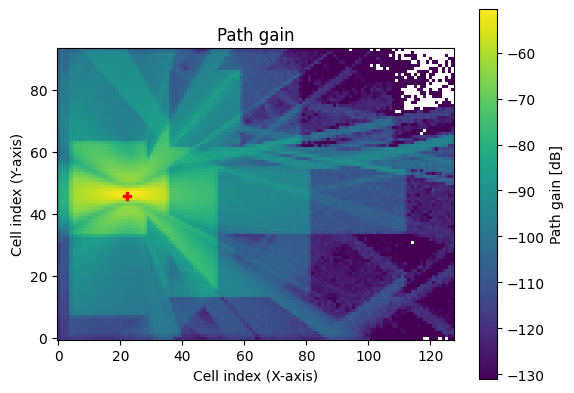

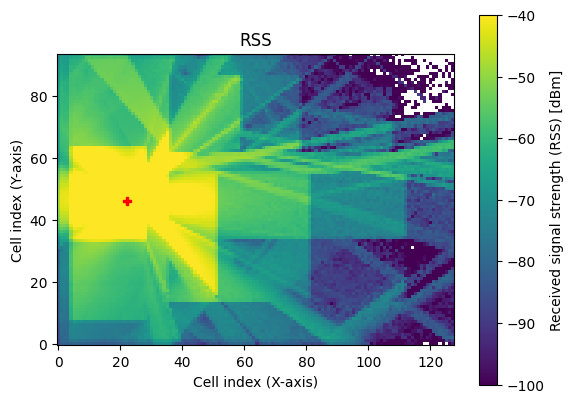

In [23]:
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMapSolver, ITURadioMaterial, PathSolver
import mitsuba as mi
import numpy as np

scene = load_scene("scenev3/final_scene_v3.xml",merge_shapes=False)
scene.frequency = 29.5e9 #Hz
scene.synthetic_array = True

#Create material and thickness
matAndThick = ITURadioMaterial(name="plasterboard",
                               itu_type="plasterboard",
                               thickness=0.06)#m

#See objects and materials from blender
for name, obj in scene.objects.items():
    print(f'\033[1m{name:}---{obj.radio_material.name}\033[0m')
    if obj.radio_material.name == "itu_plasterboard":
        obj.radio_material = matAndThick #Applies thickness
        print("    -Thickness applied")

# Configure antennas arrays
scene.tx_array = PlanarArray( #Transmitter
    num_rows=1,
    num_cols=4,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization = "V")

scene.rx_array = PlanarArray( #Receiver
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

#Create transmitter and receiver
tx = Transmitter(name="tx",
                 position=mi.Point3f(-7, 0, 1),
                 orientation=mi.Point3f(0, 0, 0),
                 power_dbm=37)
scene.add(tx)
tx.look_at([-6, 0, 2])
nReceptor = 22
positions = ( (-6.5 , 4),   #1
              (-4   , 3),   #2
              (-2   , 3),   #3
              (0    , 3),   #4
              (1    , 1.2), #5
              (-2   , 1.2), #6
              (-6   , 1.2), #7
              (-4.5 , 1.2), #7b
              (-5.3 , -0.5),#8
              (-2.5 , 0.2), #9
              (0.5  , 0.5), #10
              (2.5  , 1),   #11
              (3    , -1),  #12
              (1    , -2),  #13
              (-2   , -2),  #14
              (-5.3 , -2.5),#15
              (-7   , -2.5),#16
              (-5.7 , -4),  #17
              (-4   , -4),  #17b
              (-2   , -4),  #18
              (1    , -4),  #19
              (3    , -4))  #20
for i in range(nReceptor):
    posx = positions[i][0]
    posy = positions[i][1]
    posz = 1
    rx = Receiver(name=f"rx_{i}",
                 position=mi.Point3f(posx, posy, posz),
                 orientation=mi.Point3f(0.0, 0.0, 0.0))
    scene.add(rx)

# Radio Map
rmSolver = RadioMapSolver()
rm = rmSolver(scene,
              samples_per_tx= int(1e8),
              max_depth=6,
              cell_size=(0.1, 0.1),
              los = True,
              specular_reflection = True,
              diffuse_reflection = True,
              refraction = True,
              diffraction = True,
              edge_diffraction = True,
              diffraction_lit_region = True,
              stop_threshold = -131)

#Paths
solver  = PathSolver()
paths = solver(scene,
               max_depth=6,
               max_num_paths_per_src= int(1e6),
               samples_per_src= int(1e6),
               synthetic_array=True,
               los=True,
               specular_reflection=True,
               diffuse_reflection=True,
               refraction=True,
               edge_diffraction=True,
               diffraction_lit_region=True)

scene.preview(radio_map=rm, clip_at=3)
rm.show(metric='path_gain', vmin=-131)
rm.show(metric='rss', vmin=-100, vmax=-40)

#Ampltiudes and TDoA from CIR
a, tau = paths.cir(out_type="numpy")

print("rx, rx_ant, tx, tx_ant, paths, batch")
print(a.shape)
print("rxs, txs, paths")
print(tau.shape)

tx_power_dbm = 37

print("\n--- RSS ---")

for rx in range(nReceptor):
    amp = a[rx, 0, 0, :, :, 0]
    power = np.sum(np.abs(amp)**2)
    dBPower = tx_power_dbm + 10*np.log10(power + 1e-15)
    print(f"\nReceptor {rx} ubicado en {positions[rx]}tiene RSS {dBPower:.2f} dBm")